# 1. Library

In [1]:
!pip install -q transformers datasets accelerate

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    AutoTokenizer, 
    AutoConfig, 
    XLMRobertaPreTrainedModel,
    XLMRobertaModel,
    Trainer, 
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed
)
from transformers.modeling_outputs import SequenceClassifierOutput

In [3]:
def set_up(seed=42):
    set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
SEED = 42
set_up(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


# 2. Load Data

In [5]:
train_df = pd.read_csv("/kaggle/input/datasets/jun1801/legalai/train_expanded.csv")
val_df = pd.read_csv("/kaggle/input/datasets/jun1801/legalai/val_expanded.csv")
test_df = pd.read_csv("/kaggle/input/datasets/jun1801/legalai/test_expanded.csv")

In [6]:
similarity_mapping = {
    "Dissimilar": "0",
    "Low similar": "1",
    "Similar": "2",
    "High similar": "3",
    "Identical": "4",
}

for df in [train_df, val_df, test_df]:
    df.drop(columns=["Pair ID"], inplace=True)
    df["Similarity"] = df["Similarity"].fillna("High similar").replace(similarity_mapping).astype(int)

In [7]:
all_classes = sorted(list(set(
    train_df["Class 1"].tolist() + train_df["Class 2"].tolist() +
    val_df["Class 1"].tolist() + val_df["Class 2"].tolist() +
    test_df["Class 1"].tolist() + test_df["Class 2"].tolist()
)))

special_tokens_list = [f"[CLASS_{c}]" for c in all_classes]
class_to_token = {c: f"[CLASS_{c}]" for c in all_classes}
class_to_id = {c: i for i, c in enumerate(all_classes)}
NUM_PRODUCT_CLASSES = len(all_classes)

print(f"Total Product Classes: {NUM_PRODUCT_CLASSES}")
print(f"Sample Special Tokens: {special_tokens_list}")

Total Product Classes: 45
Sample Special Tokens: ['[CLASS_1]', '[CLASS_2]', '[CLASS_3]', '[CLASS_4]', '[CLASS_5]', '[CLASS_6]', '[CLASS_7]', '[CLASS_8]', '[CLASS_9]', '[CLASS_10]', '[CLASS_11]', '[CLASS_12]', '[CLASS_13]', '[CLASS_14]', '[CLASS_15]', '[CLASS_16]', '[CLASS_17]', '[CLASS_18]', '[CLASS_19]', '[CLASS_20]', '[CLASS_21]', '[CLASS_22]', '[CLASS_23]', '[CLASS_24]', '[CLASS_25]', '[CLASS_26]', '[CLASS_27]', '[CLASS_28]', '[CLASS_29]', '[CLASS_30]', '[CLASS_31]', '[CLASS_32]', '[CLASS_33]', '[CLASS_34]', '[CLASS_35]', '[CLASS_36]', '[CLASS_37]', '[CLASS_38]', '[CLASS_39]', '[CLASS_40]', '[CLASS_41]', '[CLASS_42]', '[CLASS_43]', '[CLASS_44]', '[CLASS_45]']


In [8]:
MODEL_NAME = "BAAI/bge-reranker-v2-m3"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

num_added_toks = tokenizer.add_tokens(special_tokens_list)
print(f"Đã thêm {num_added_toks} token class vào từ điển")

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Đã thêm 45 token class vào từ điển


In [9]:
def create_dataset(df):
    new_rows = []
    mask_token = tokenizer.mask_token
    
    for _, row in df.iterrows():
        c1, t1 = row["Class 1"], row["Term 1 Expand"]
        c2, t2 = row["Class 2"], row["Term 2 Expand"]
        label = row["Similarity"]
        
        text1_a = f"{mask_token} {t1}"
        text2_a = f"{class_to_token.get(c2, '')} {t2}"
        label_aux_a = class_to_id.get(c1, 0)
        
        new_rows.append({
            "text1": text1_a, "text2": text2_a, 
            "labels": label, "aux_labels": label_aux_a
        })
        
        text1_b = f"{class_to_token.get(c1, '')} {t1}"
        text2_b = f"{mask_token} {t2}"
        label_aux_b = class_to_id.get(c2, 0)
        
        new_rows.append({
            "text1": text1_b, "text2": text2_b, 
            "labels": label, "aux_labels": label_aux_b
        })

    return pd.DataFrame(new_rows)

In [10]:
train_aug_df = create_dataset(train_df)
val_aug_df = create_dataset(val_df)
test_aug_df = create_dataset(test_df)

In [11]:
def preprocess_dataset(examples):
    tokenized = tokenizer(
        examples["text1"], 
        examples["text2"], 
        truncation=True, 
        max_length=64, 
        padding=False
    )
    tokenized["labels"] = examples["labels"]
    tokenized["aux_labels"] = examples["aux_labels"]
    return tokenized

In [12]:
cols_to_remove = train_aug_df.columns.tolist() 

train_ds = Dataset.from_pandas(train_aug_df).map(
    preprocess_dataset, 
    batched=True, 
    remove_columns=cols_to_remove  
)

val_ds = Dataset.from_pandas(val_aug_df).map(
    preprocess_dataset, 
    batched=True, 
    remove_columns=val_aug_df.columns.tolist() 
)

test_ds = Dataset.from_pandas(test_aug_df).map(
    preprocess_dataset, 
    batched=True, 
    remove_columns=test_aug_df.columns.tolist() 
)
cols = ["input_ids", "attention_mask", "labels", "aux_labels"]
for ds in [train_ds, val_ds, test_ds]: 
    ds.set_format(type="torch", columns=cols)

Map:   0%|          | 0/29878 [00:00<?, ? examples/s]

Map:   0%|          | 0/4270 [00:00<?, ? examples/s]

Map:   0%|          | 0/8532 [00:00<?, ? examples/s]

In [13]:
class_weights = compute_class_weight(
    "balanced", 
    classes=np.unique(train_df["Similarity"]), 
    y=train_df["Similarity"]
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f"Class Weights: {class_weights_tensor}")

Class Weights: tensor([ 0.3618,  5.2881,  1.5700, 10.9846,  0.7583], device='cuda:0')


# 3. Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RankAwareFocalLoss(nn.Module):
    def __init__(self, num_classes=5, gamma=2.0, alpha=0.5):
        super(RankAwareFocalLoss, self).__init__()
        self.num_classes = num_classes
        self.gamma = gamma
        self.alpha = alpha
        self.register_buffer('rank_values', torch.arange(num_classes).float())

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        focal_loss = focal_loss.mean()
        probs = F.softmax(logits, dim=-1)
        
        rank_values = self.rank_values.to(logits.device)
        expected_ranks = torch.sum(probs * rank_values, dim=-1)
        
        rank_loss = F.mse_loss(expected_ranks, targets.float())

        total_loss = focal_loss + (self.alpha * rank_loss)
        
        return total_loss

In [ ]:
from transformers.modeling_outputs import SequenceClassifierOutput
import torch
import torch.nn as nn

class JointClassSimBGE(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = 5                     
        self.num_product_classes = config.num_product_classes
        
        self.mask_token_id = getattr(config, "mask_token_id", 250001)
        
        self.roberta = XLMRobertaModel(config)
        self.classifier = nn.Linear(config.hidden_size, self.num_labels)
        self.aux_classifier = nn.Linear(config.hidden_size, self.num_product_classes)
        
        self.register_buffer("class_weights", None)

        if getattr(config, "gradient_checkpointing", False):
            self.roberta.gradient_checkpointing = True
            self.roberta.config.use_cache = False
        
        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, 
                labels=None, aux_labels=None, 
                num_items_in_batch=None,
                **kwargs):
        
        outputs = self.roberta(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, **kwargs)
        
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits_sim = self.classifier(cls_output)

        is_mask_token = (input_ids == self.mask_token_id).int()
        mask_positions = is_mask_token.argmax(dim=-1) 
        
        batch_size = input_ids.size(0)
        batch_indices = torch.arange(batch_size, device=input_ids.device)
        mask_output = outputs.last_hidden_state[batch_indices, mask_positions, :]
        
        logits_aux = self.aux_classifier(mask_output)
        
        loss = None
        if labels is not None:
            loss_fct_sim = RankAwareFocalLoss(num_classes=self.num_labels, gamma=2.0, alpha=0.5)
            loss_sim = loss_fct_sim(logits_sim.view(-1, self.num_labels), labels.view(-1))
            
            loss_aux = torch.tensor(0.0).to(logits_sim.device)
            
            if aux_labels is not None and self.training:
                loss_fct_aux = nn.CrossEntropyLoss()
                loss_aux = loss_fct_aux(logits_aux.view(-1, self.num_product_classes), aux_labels.view(-1))
            
            loss = loss_sim + 0.3 * loss_aux
            
        return SequenceClassifierOutput(
            loss=loss,
            logits=logits_sim
        )

# 4. Training

In [16]:
config = AutoConfig.from_pretrained(MODEL_NAME)
config.num_labels = 5
config.num_product_classes = NUM_PRODUCT_CLASSES 

model = JointClassSimBGE.from_pretrained(
    MODEL_NAME, 
    config=config, 
    ignore_mismatched_sizes=True
)
model.resize_token_embeddings(len(tokenizer))
model.class_weights = class_weights_tensor 
model = model.to(DEVICE)

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

JointClassSimBGE LOAD REPORT from: BAAI/bge-reranker-v2-m3
Key                         | Status     | 
----------------------------+------------+-
classifier.dense.weight     | UNEXPECTED | 
classifier.dense.bias       | UNEXPECTED | 
classifier.out_proj.weight  | UNEXPECTED | 
classifier.out_proj.bias    | UNEXPECTED | 
aux_classifier.bias         | MISSING    | 
classifier.bias             | MISSING    | 
roberta.pooler.dense.bias   | MISSING    | 
roberta.pooler.dense.weight | MISSING    | 
classifier.weight           | MISSING    | 
aux_classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nl

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, mean_absolute_error

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(labels, tuple):
        labels = labels[0]
    
    if isinstance(logits, tuple):
        logits = logits[0]
    
    preds = np.argmax(logits, axis=-1)
    
    qwk = cohen_kappa_score(labels, preds, weights="quadratic")
    mae = mean_absolute_error(labels, preds)
    
    return {
        "accuracy": accuracy_score(labels, preds), 
        "f1_macro": f1_score(labels, preds, average="macro"),
        "qwk": qwk,
        "mae": mae
    }

In [18]:
training_args = TrainingArguments(
    output_dir="./bge_joint_class_sim",
    learning_rate=1.5e-5,           
    num_train_epochs=10, 
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    dataloader_num_workers=2,
    per_device_eval_batch_size=16,
    lr_scheduler_type="cosine",    
    warmup_ratio=0.1,              
    weight_decay=0.01,              
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    logging_steps=10,
    report_to="none", 
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro", 
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    data_seed=SEED,
    remove_unused_columns=False 
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)

print("Bắt đầu Training...")
trainer.train()

Bắt đầu Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Qwk,Mae
1,3.080797,0.518052,0.853396,0.564287,0.887465,0.290867
2,0.931905,0.474018,0.866745,0.655280,0.914165,0.238876
3,0.752542,0.465444,0.877752,0.699822,0.923386,0.213583
4,0.216488,0.475931,0.890867,0.710833,0.932772,0.188525
5,0.197397,0.532037,0.899532,0.768963,0.932903,0.181265
6,0.254923,0.520067,0.911710,0.779487,0.941473,0.159953
7,0.033465,0.566915,0.910539,0.771746,0.940821,0.161124
8,0.003521,0.575814,0.910304,0.763357,0.942465,0.158314
9,0.014957,0.575634,0.908665,0.760522,0.938985,0.164403
10,0.001271,0.573907,0.910070,0.767530,0.939153,0.162295


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=9340, training_loss=0.9868289098401836, metrics={'train_runtime': 7346.113, 'train_samples_per_second': 40.672, 'train_steps_per_second': 1.271, 'total_flos': 2.203940032845804e+16, 'train_loss': 0.9868289098401836, 'epoch': 10.0})

# 5. Evaluate

In [25]:
test_output = trainer.predict(test_ds)
predictions = test_output.predictions

if isinstance(predictions, tuple):
    predictions = predictions[0]

reshaped_logits = predictions.reshape(-1, 2, 5)
avg_logits = reshaped_logits.mean(axis=1)

test_preds = np.argmax(avg_logits, axis=-1)
test_true = test_df["Similarity"].values

In [27]:
result_df = pd.DataFrame({
    "label": test_true,
    "pred": test_preds,
})

In [28]:
result_df

,label,pred
0,4,4
1,4,4
2,0,0
3,0,0
4,2,2
...,...,...
4261,4,4
4262,0,0
4263,4,4
4264,2,2


In [ ]:
import numpy as np
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
def safe_div(a, b):
    return float(a) / float(b) if b else 0.0

def main(df):
    y_true = df["label"].to_numpy()
    y_pred = df["pred"].to_numpy()

    labels = list(range(5))
    label_names = ['Dissimilar (0)', 'Low (1)', 'Similar (2)', 'High (3)', 'Identical (4)']
    K = len(labels)
    idx = {c: i for i, c in enumerate(labels)}

    cm = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if t in idx and p in idx:
            cm[idx[t], idx[p]] += 1

    TP = np.diag(cm)
    FP = cm.sum(axis=0) - TP
    FN = cm.sum(axis=1) - TP
    TN = cm.sum() - (TP + FP + FN)

    per_class = []
    for i, c in enumerate(labels):
        support = cm[i, :].sum()
        precision = safe_div(TP[i], TP[i] + FP[i])
        recall = safe_div(TP[i], TP[i] + FN[i])
        f1 = safe_div(2 * precision * recall, precision + recall)
        acc = safe_div(TP[i] + TN[i], TP[i] + TN[i] + FP[i] + FN[i])
        per_class.append({
            "class": c,
            "support": int(support),
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    TP_micro = TP.sum()
    FP_micro = FP.sum()
    FN_micro = FN.sum()

    micro_precision = safe_div(TP_micro, TP_micro + FP_micro)
    micro_recall = safe_div(TP_micro, TP_micro + FN_micro)
    micro_f1 = safe_div(2 * micro_precision * micro_recall, micro_precision + micro_recall)

    macro_precision = np.mean([r["precision"] for r in per_class])
    macro_recall = np.mean([r["recall"] for r in per_class])
    macro_f1 = np.mean([r["f1"] for r in per_class])

    overall_acc = safe_div((y_true == y_pred).sum(), len(y_true))

    mae = np.mean(np.abs(y_true - y_pred))
    
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

    print("Per-class metrics (class | support | accuracy | precision | recall | f1):")
    for r in per_class:
        print(f"{r['class']:>2} | {r['support']:>6} | {r['accuracy']:.4f} | {r['precision']:.4f} | {r['recall']:.4f} | {r['f1']:.4f}")

    print("\nOverall accuracy:", f"{overall_acc:.4f}")
    print("Micro Precision | Recall | F1:", f"{micro_precision:.4f}", f"{micro_recall:.4f}", f"{micro_f1:.4f}")
    print("Macro Precision | Recall | F1:", f"{macro_precision:.4f}", f"{macro_recall:.4f}", f"{macro_f1:.4f}")
    
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")
    
    print("\nConfusion Matrix (Hàng = Thực tế, Cột = Dự đoán):")
    header = "    " + "".join([f" P{c:>3}" for c in labels])
    print(header)
    print("   " + "-" * len(header))
    for i, row in enumerate(cm):
        print(f"T{labels[i]} |" + "".join([f"{val:>4}" for val in row]))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names)
    plt.savefig('confusion_matrix.pdf', format='pdf', bbox_inches='tight')
    plt.savefig('confusion_matrix.png', format='png', dpi=300, bbox_inches='tight')
    
    plt.show()
    return overall_acc, mae, qwk

Per-class metrics (class | support | accuracy | precision | recall | f1):
 0 |   2360 | 0.9637 | 0.9697 | 0.9644 | 0.9671
 1 |    161 | 0.9789 | 0.7554 | 0.6522 | 0.7000
 2 |    543 | 0.9358 | 0.7159 | 0.8214 | 0.7650
 3 |     77 | 0.9852 | 0.5875 | 0.6104 | 0.5987
 4 |   1125 | 0.9644 | 0.9517 | 0.9111 | 0.9310

Overall accuracy: 0.9140
Micro Precision | Recall | F1: 0.9140 0.9140 0.9140
Macro Precision | Recall | F1: 0.7961 0.7919 0.7924
Mean Absolute Error (MAE): 0.1545
Quadratic Weighted Kappa (QWK): 0.9442

Confusion Matrix (Hàng = Thực tế, Cột = Dự đoán):
     P  0 P  1 P  2 P  3 P  4
   -----------------------------
T0 |2276  12  58   4  10
T1 |  18 105  32   4   2
T2 |  40  16 446   8  33
T3 |   2   2  19  47   7
T4 |  11   4  68  171025


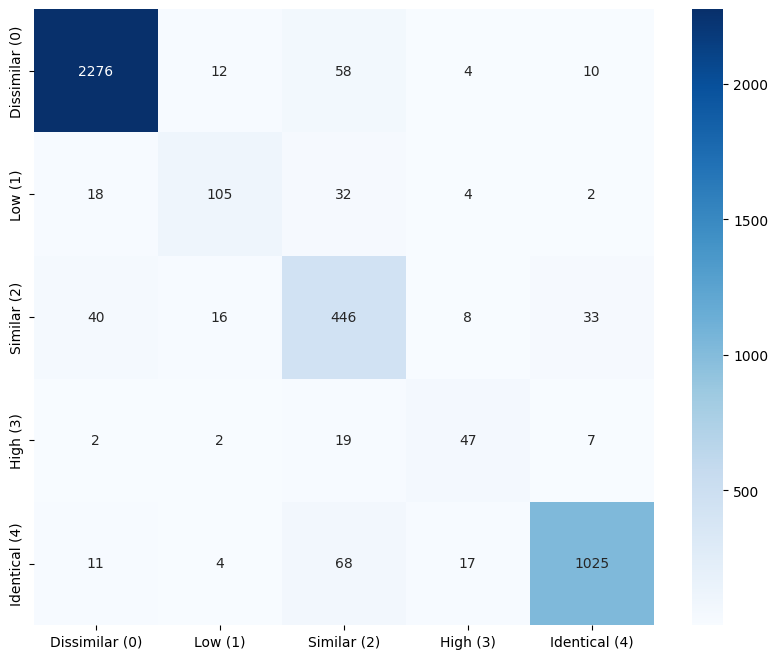

(0.9139709329582747,
 np.float64(0.15447726207219878),
 np.float64(0.944237672916768))

In [33]:
main(result_df)

# 6. Save

In [ ]:
result_df.to_csv("result_bertclass.csv", index=False)
print("Saved!")

In [ ]:
import shutil
save_path = "./bge_joint_class_sim"
print(f"Saving to: {save_path} ...")
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
shutil.make_archive("bge_joint_class_sim", 'zip', save_path)
print("Compressed!")